## Perform feature engineering

**Introduction**

In this activity, you are working for a firm that provides insights to the National Basketball Association (NBA), a professional North American basketball league. You will help NBA managers and coaches identify which players are most likely to thrive in the high-pressure environment of professional basketball and help the team be successful over time.

To do this, you will analyze a subset of data that contains information about NBA players and their performance records. You will conduct feature engineering to determine which features will most effectively predict whether a player's NBA career will last at least five years. The insights gained then will be used in the next stage of the project: building the predictive model.

In [3]:
#Import Library
import pandas as pd

In [8]:
# Load the data
nba_df = pd.read_csv('nba-players.csv',index_col = 0)
nba_df.head()

,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


In [9]:
nba_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         1340 non-null   str    
 1   gp           1340 non-null   int64  
 2   min          1340 non-null   float64
 3   pts          1340 non-null   float64
 4   fgm          1340 non-null   float64
 5   fga          1340 non-null   float64
 6   fg           1340 non-null   float64
 7   3p_made      1340 non-null   float64
 8   3pa          1340 non-null   float64
 9   3p           1340 non-null   float64
 10  ftm          1340 non-null   float64
 11  fta          1340 non-null   float64
 12  ft           1340 non-null   float64
 13  oreb         1340 non-null   float64
 14  dreb         1340 non-null   float64
 15  reb          1340 non-null   float64
 16  ast          1340 non-null   float64
 17  stl          1340 non-null   float64
 18  blk          1340 non-null   float64
 19  tov          1340

**Question: What do you observe about the number of rows and the number of columns in the data?**
There are 1,340 rows and 21 columns in the data.

The following table provides a description of the data in each column. This metadata comes from the data source, which is listed in the references section of this lab.

Column Name	Column Description
name	Name of NBA player
gp	Number of games played
min	Number of minutes played per game
pts	Average number of points per game
fgm	Average number of field goals made per game
fga	Average number of field goal attempts per game
fg	Average percent of field goals made per game
3p_made	Average number of three-point field goals made per game
3pa	Average number of three-point field goal attempts per game
3p	Average percent of three-point field goals made per game
ftm	Average number of free throws made per game
fta	Average number of free throw attempts per game
ft	Average percent of free throws made per game
oreb	Average number of offensive rebounds per game
dreb	Average number of defensive rebounds per game
reb	Average number of rebounds per game
ast	Average number of assists per game
stl	Average number of steals per game
blk	Average number of blocks per game
tov	Average number of turnovers per game
target_5yrs	1 if career duration >= 5 yrs, 0 otherwise


**Question: Based on the preceding tables, which columns are numerical and which columns are categorical?**
Based on the preceding tables, the name column is categorical, and the rest of the columns are numerical.

In [10]:
#Check for missing values
nba_df.isna().sum()

name           0
gp             0
min            0
pts            0
fgm            0
fga            0
fg             0
3p_made        0
3pa            0
3p             0
ftm            0
fta            0
ft             0
oreb           0
dreb           0
reb            0
ast            0
stl            0
blk            0
tov            0
target_5yrs    0
dtype: int64

**Question: What do you observe about the missing values in the columns?** All columns in this dataset have 0 missing values.

**Question: Why is it important to check for missing values?** Checking for missing values is an important step in data exploration. It's important to handle them by cleaning the data.

## Statistical tests
Next, use a statistical technique to check the class balance in the data. To understand how balanced the dataset is in terms of class, display the percentage of values that belong to each class in the target column. In this context, class 1 indicates an NBA career duration of at least five years, while class 0 indicates an NBA career duration of less than five years.

In [17]:
# Display percentage (%) of values for each class (1, 0) represented in the target column of this dataset.
nba_df['target_5yrs'].value_counts(normalize=True) * 100

target_5yrs
1    62.014925
0    37.985075
Name: proportion, dtype: float64

**Question: What do you observe about the class balance in the target column?**

About 62% of the values in the target columm belong to class 1, and about 38% of the values belong to class 0. In other words, about 62% of players represented by this data have an NBA career duration of at least five years, and about 38% do not.
The dataset is not perfectly balanced, but an exact 50-50 split is a rare occurance in datasets, and a 62-38 split is not too imbalanced. However, if the majority class made up 90% or more of the dataset, then that would be of concern, and it would be prudent to address that issue through techniques like upsampling and downsampling.
**Question: Why is it important to check class balance?**

If there is a lot more representation of one class than another, then the model may be biased toward the majority class. When this happens, the predictions may be inaccurate.

## Feature Selection

**Question: Which columns would you select and avoid selecting as features, and why? Keep in mind the goal is to identify features that will serve as useful predictors for the target variable, target_5yrs.**

1. You should avoid selecting the name column as a feature. A player's name is not helpful in determining their career duration. Moreover, it may not be ethical or fair to predict a player's career duration based on a name.
2. The number of games a player has played in may not be as important in determining their career duration as the number of points they have earned. While you could say that someone who has played in more games may have more practice and experience, the points they earn during the games they played in would speak more to their performance as a player. This, in turn, would influence their career duration. So, the gp column on its own may not be a helpful feature. However, **gp and pts could be combined to get the total number of points earned across the games played**, and that result could be a helpful feature. That approach can be implemented later in the feature engineering process—in feature extraction.
3. If the number of points earned across games will be extracted as a feature, then that could be combined with the **number of minutes played across games (min * gp)** to extract another feature. This could be a measure of players' efficiency and could help in predicting players' career duration. min on its own may not be useful as a feature for the same reason as gp.
4. There are three different columns that give information about field goals. The **percent of field goals a player makes (fg)** says more about their performance than the number of field goals they make (fgm) or the number of field goals they attempt (fga). The percent gives more context, as it takes into account both how many field goals a player successfully made and how many field goals they attempted in total. This allows for a more meaningful comparison between players. The same logic applies to the percent of three-point field goals made, as well as the percent of free throws made.
5. There are columns for the number offensive rebounds (oreb), the number of defensive rebounds (dreb), and **the number of rebounds overall (reb)** . Because the overall number of rebounds should already incorporate both offensive and defensive rebounds, it would make sense to use the overall as a feature.
The number of assists (ast), steals (stl), blocks (blk), and turnovers (tov) also provide information about how well players are performing in games, and thus, could be helpful in predicting how long players last in the league.

Therefore, at this stage of the feature engineering process, it would be most effective to select the following columns:

gp, min, pts, fg, 3p, ft, reb, ast, stl, blk, tov.

In [19]:
# Select the columns to proceed with and save the DataFrame in new variable `selected_data`.
selected_data = nba_df[["gp", "min", "pts", "fg", "3p", "ft", "reb", "ast", "stl", "blk", "tov", "target_5yrs"]]
selected_data.head()

,gp,min,pts,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs
0,36,27.4,7.4,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0
1,35,26.9,7.2,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0
2,74,15.3,5.2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0
3,58,11.6,5.7,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1
4,48,11.5,4.5,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1


**Feature transformation**
An important aspect of feature transformation is feature encoding. If there are categorical columns that you would want to use as features, those columns should be transformed to be numerical. This technique is also known as feature encoding.

**Question: Why is feature transformation important to consider? Are there any transformations necessary for the features you want to use?**

Many types of models are designed in a way that requires the data coming in to be numerical. So, transforming categorical features into numerical features is an important step.
In this particular dataset, name is the only categorical column and the other columns are numerical . Given that name is not selected as a feature, all of the features that are selected at this point are already numerical and do not require transformation.

**Question: Which columns lend themselves to feature extraction?**

The gp, pts, min columns lend themselves to feature extraction.
gp represents the total number of games a player has played in, and pts represents the average number of points the player has earned per game. It might be helpful to combine these columns to get the total number of points the player has earned across the games and use the result as a new feature, which could be added into a new column named total_points. The total points earned by a player can reflect their performance and shape their career longevity.
The min column represents the average number of minutes played per game. total_points could be combined with min and gp to extract a new feature: points earned per minute. This can be considered a measure of player efficiency, which could shape career duration. This feature can be added into a column named efficiency.

Extract two features that you think would help predict target_5yrs. Then, create a new variable named 'extracted_data' that contains features from 'selected_data', as well as the features being extracted.

In [20]:
# Make a copy of `selected_data` 
extracted_data = selected_data.copy()

In [21]:
# Add a new column named `total_points`; 
extracted_data['total_points'] = extracted_data['gp'] * extracted_data['pts']

# Calculate  `total minutes = total games * avg minutes per game`; 
extracted_data['gp'] * extracted_data['min']

# Add a new column named `efficiency` which is total points / total minutes; 
extracted_data['efficiency'] = extracted_data['total_points'] / (extracted_data['gp'] * extracted_data['min'])

extracted_data.head()

,gp,min,pts,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,36,27.4,7.4,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,35,26.9,7.2,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,74,15.3,5.2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,58,11.6,5.7,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,48,11.5,4.5,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304


Now, to prepare for **the Naive Bayes model** that will be built in a later lab, clean the extracted data and ensure ensure it is concise. Naive Bayes involves an assumption that features are independent of each other given the class. In order to satisfy that criteria, if certain features are aggregated to yield new features, it may be necessary to remove those original features. Therefore, drop the columns that were used to extract new features.

Note: There are other types of models that do not involve independence assumptions, so this would not be required in those instances. In fact, keeping the original features may be beneficial.

In [23]:
# Remove any columns from `extracted_data` that are no longer needed.
# Remove `gp`, `pts`, and `min` from `extracted_data`.
extracted_data = extracted_data.drop(['gp','pts','min'], axis = 1)
extracted_data.head()

,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304


**What are some key takeaways that you learned during this lab?**

1. It is important to check for class balance in a dataset, particularly in the context of feature engineering and predictive modeling. If the target column in a dataset has more than 90% of its values belonging to one class, it is recommended to redistribute the data; otherwise, once a model is trained on the imbalanced data and predictions are made, the predictions may be biased.
2. Feature selection involves choosing features that help predict the target variable and removing columns that may not be helpful for prediction. In this process, and throughout feature engineering, it is important to make ethical considerations.
3. Feature transformation involves transforming features so that they are more usable for future modeling purposes, which includes encoding categorical features to turn them into numerical features.
4. Feature extraction involves combining existing columns meaningfully to construct new features that would help improve prediction.
**What summary would you provide to stakeholders? Consider key attributes to be shared from the data, as well as upcoming project plans.**

The following attributes about player performance could help predict their NBA career duration and should be included in a presentation to stakeholders: field goals, three-point field goals, free throws, rebounds, assists, steals, blocks, turnovers, total points, and efficiency as points per minute.
It would be important to explain that these attributes, along with a relevant dataset, will be used in the next stage of the project. At that point, a model will be built to predict a player's career duration. Insights gained will be shared with stakeholders once the project is complete. Stakeholders would also appreciate being provided with a timeline and key deliverables that they can expect to receive.

## Build a Naive Bayes model

**Introduction**
Naive Bayes models can be valuable to use any time you are doing work with predictions because they give you a way to account for new information. In today's world, where data is constantly evolving, modeling with Naive Bayes can help you adapt quickly and make more accurate predictions about what could occur.

For this activity, you work for a firm that provides insights for management and coaches in the National Basketball Association (NBA), a professional basketball league in North America. The league is interested in retaining players who can last in the high-pressure environment of professional basketball and help the team be successful over time. In the previous activity, you analyzed a subset of data that contained information about the NBA players and their performance records. You conducted feature engineering to determine which features would most effectively predict a player's career duration. You will now use those insights to build a model that predicts whether a player will have an NBA career lasting five years or more.

The data for this activity consists of performance statistics from each player's rookie year. There are 1,341 observations, and each observation in the data represents a different player in the NBA. Your target variable is a Boolean value that indicates whether a given player will last in the league for five years. Since you previously performed feature engineering on this data, it is now ready for modeling.

In [24]:
#Display  the dataset
extracted_data.head(10)

,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304
5,42.3,32.5,73.2,0.8,1.8,0.4,0.0,0.7,0,277.5,0.324561
6,43.5,50.0,81.1,2.0,0.6,0.2,0.1,0.7,1,409.2,0.605505
7,41.5,30.0,87.5,1.7,0.2,0.2,0.1,0.7,1,273.6,0.553398
8,39.2,23.3,71.4,0.8,2.3,0.3,0.0,1.1,0,156.0,0.242424
9,38.3,21.4,67.8,1.1,0.3,0.2,0.0,0.7,0,155.4,0.435294


**Model preparation**
Isolate your target and predictor variables
Separately define the target variable (target_5yrs) and the features.

In [25]:
# Define the y (target) variable.
y = extracted_data['target_5yrs']

# Define the X (predictor) variables.
X = extracted_data.drop('target_5yrs', axis=1)

In [26]:
# Display the first 10 rows of your target data.
y.head(10)

0    0
1    0
2    0
3    1
4    1
5    0
6    1
7    1
8    0
9    0
Name: target_5yrs, dtype: int64

**Question: What do you observe about the your target variable?**
Given that the target variable contains both 1 and 0 indicates that it is binary and requires a model suitable for binary classification.

In [27]:
# Display the first 10 rows of your predictor variables.
X.head(10)

,fg,3p,ft,reb,ast,stl,blk,tov,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,216.0,0.391304
5,42.3,32.5,73.2,0.8,1.8,0.4,0.0,0.7,277.5,0.324561
6,43.5,50.0,81.1,2.0,0.6,0.2,0.1,0.7,409.2,0.605505
7,41.5,30.0,87.5,1.7,0.2,0.2,0.1,0.7,273.6,0.553398
8,39.2,23.3,71.4,0.8,2.3,0.3,0.0,1.1,156.0,0.242424
9,38.3,21.4,67.8,1.1,0.3,0.2,0.0,0.7,155.4,0.435294


**Question: What do you observe about the your predictor variables?**

The data indicates that all of the predictor variables are continuous numerical values, so it is important that the model selected is suitable for continuous features.

**Perform a split operation on your data**
Divide your data into a training set (75% of data) and test set (25% of data). 

In [31]:
from sklearn import naive_bayes
from sklearn import model_selection
from sklearn import metrics

In [33]:
X_train,X_test,y_train,y_test = model_selection.train_test_split(X,y,test_size = 0.25, random_state = 0)


In [34]:
# Print the shape (rows, columns) of the output from the train-test split.

# Print the shape of X_train.
print(X_train.shape)
# Print the shape of X_test.
print(X_test.shape)

# Print the shape of y_train.
print(y_train.shape)
# Print the shape of y_test.
print(y_test.shape)

(1005, 10)
(335, 10)
(1005,)
(335,)


**Question: How many rows are in each of the outputs?**

Each training DataFrame contains 1,005 rows, while each test DataFrame contains 335 rows. Additionally, there are 10 columns in each X DataFrame, with only one column in each y DataFrame.

**Question: What was the effect of the train-test split?**

The effect of the train-test split showed an approximately 75% training and 25% test split.

**Model building**
**Question: Which Naive Bayes algorithm should you use?**

Using the assumption that features are normally distributed and continuous, the Gaussian Naive Bayes algorithm is most appropriate for our data. While our data may not perfectly adhere to these assumptions, this model will still yield the most usable and accurate results.

**Fit your model to your training data and predict on your test data**

In [35]:
# Assign `nb` to be the appropriate implementation of Naive Bayes.
gnb = naive_bayes.GaussianNB()

# Fit the model on your training data.
gnb.fit(X_train,y_train)

# Apply your model to predict on your test data. Call this "y_pred".
y_pred = gnb.predict(X_test)

**Leverage metrics to evaluate your model's performance**

In [39]:
#print evaluation metrics
print('Accuracy:', '%.3f' % metrics.accuracy_score(y_test,y_pred))
print('Precision:', '%.3f' % metrics.precision_score(y_test,y_pred))
print('Recall:', '%.3f' % metrics.recall_score(y_test,y_pred))
print('F1 Score:', '%.3f' % metrics.f1_score(y_test,y_pred))

Accuracy: 0.690
Precision: 0.841
Recall: 0.586
F1 Score: 0.690


**Question: What is the accuracy score for your model, and what does this tell you about the success of the model's performance?**

The accuracy score for this model is 0.6896, or 69.0% accurate.
It’s a moderate level of performance — not terrible, but not strong enough to rely on without deeper evaluation.Accuracy alone can be misleading, especially if dataset is imbalanced. 

**Can you evaluate the success of your model by using the accuracy score exclusively?**

In classification problems, accuracy is useful to know but may not be the best metric by which to evaluate this model. While accuracy is often the most intuitive metric, it is a poor evaluation metric in some cases. In particular, if you have imbalanced classes, a model could appear accurate but be poor at balancing false positives and false negatives.

**Question: What are the precision and recall scores for your model, and what do they mean? Is one of these scores more accurate than the other?**

Precision and recall scores are both useful to evaluate the correct predictive capability of a model because they balance the false positives and false negatives inherent in prediction.

The model shows a precision score of 0.8406, suggesting the model is quite good at predicting true positives—meaning the player will play longer than five years—while balancing false positives. The recall score of 0.5859 shows worse performance in predicting true negatives—where the player will not play for five years or more—while balancing false negatives.These two metrics combined can give a better assessment of model performance than accuracy does alone.

**Question: What is the F1 score of your model, and what does this score mean?**

The F1 score balances the precision and recall performance to give a combined assessment of how well this model delivers predictions. In this case, the F1 score is 0.6905, which suggests reasonable predictive power in this model.

**Gain clarity with the confusion matrix**

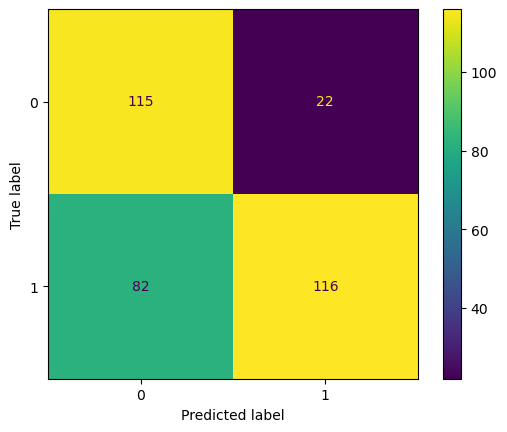

In [40]:
# Construct and display your confusion matrix.
cm = metrics.confusion_matrix(y_test, y_pred)
viz = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = gnb.classes_)
viz.plot()

**Question: What do you notice when observing your confusion matrix, and does this correlate to any of your other calculations?**

The top left to bottom right diagonal in the confusion matrix represents the correct predictions, and the ratio of these squares showcases the accuracy.

The concentration of true positives stands out relative to false positives. This ratio is why the precision score is so high (0.8406).

True negatives and false negatives are closer in number, which explains the worse recall score.

**Considerations**
**What are some key takeaways that you learned from this lab?**

The evaluation of the model is important to inform if the model has delivered accurate predictions.
Splitting the data was important for ensuring that there was new data for the model to test its predictive performance.
Each metric provided an evaluation from a different standpoint, and accuracy alone was not a strong way to evaluate the model.
Effective assessments balance the true/false positives versus true/false negatives through the confusion matrix and F1 score.
**How would you present your results to your team?**

Showcase the data used to create the prediction and the performance of the model overall.
Review the sample output of the features and the confusion matrix to indicate the model's performance.
Highlight the metric values, emphasizing the F1 score.
**How would you summarize your findings to stakeholders?**

The model created provides some value in predicting an NBA player's chances of playing for five years or more.
Notably, the model performed better at predicting true positives than it did at predicting true negatives. In other words, it more accurately identified those players who will likely play for more than five years than it did those who likely will not.